# IEEE 57-Bus DC-OPF - Original
**Author:** Jewook Park  
**Date:** October 2025  
**Description:** Basic DC-OPF for IEEE 57-bus system without line switching

## Setup and Data Loading

In [1]:
import os
os.environ["GRB_LICENSE_FILE"] = "/Users/a/Desktop/VIP/sc-opf/API key/gurobi.lic"
import re
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)

In [2]:
def extract_matrix_block(lines, varname):
    in_block, matrix_lines = False, []
    for line in lines:
        if line.strip().startswith(f"{varname} = ["): in_block = True; continue
        if in_block:
            if line.strip().startswith("];"): break
            clean = re.sub(r'%.*', '', line).strip().rstrip(';')
            if clean: matrix_lines.append(clean)
    return np.array([[float(x) for x in line.split()] for line in matrix_lines])

with open('data/pglib_opf_case57_ieee.m', 'r') as f: lines = f.readlines()
bus_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.bus'), columns=['bus_i','type','Pd','Qd','Gs','Bs','area','Vm','Va','baseKV','zone','Vmax','Vmin'])
gen_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.gen'), columns=['bus','Pg','Qg','Qmax','Qmin','Vg','mBase','status','Pmax','Pmin'])
branch_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.branch'), columns=['fbus','tbus','r','x','b','rateA','rateB','rateC','ratio','angle','status','angmin','angmax'])
gencost_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.gencost'), columns=['model','startup','shutdown','n','c2','c1','c0'])
print(f"Loaded: {len(bus_df)} buses, {len(branch_df)} branches, {len(gen_df)} generators")

Loaded: 57 buses, 80 branches, 7 generators


## DC-OPF Model

In [3]:
def define_dc_opf_model(bus_df, branch_df, gen_df, gencost_df):
    model = gp.Model("DC-OPF-57Bus")
    buses, branches, generators = bus_df['bus_i'].values, branch_df.index, gen_df.index
    Pd = dict(zip(bus_df['bus_i'], bus_df['Pd']))
    gen_at_bus = {bus: gen_df[gen_df['bus'] == bus].index.tolist() for bus in buses}
    
    # Variables
    Pg = model.addVars(generators, name="Pg")
    theta = model.addVars(buses, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="theta")
    P_line = model.addVars(branches, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="P_line")
    
    # Objective
    obj = gp.QuadExpr()
    for i in generators:
        c2, c1, c0 = gencost_df.loc[i, 'c2'], gencost_df.loc[i, 'c1'], gencost_df.loc[i, 'c0']
        obj += c2 * Pg[i] * Pg[i] + c1 * Pg[i] + c0
    model.setObjective(obj, GRB.MINIMIZE)
    
    # Reference bus
    ref_bus = bus_df[bus_df['type'] == 3]['bus_i'].values[0]
    model.addConstr(theta[ref_bus] == 0, name="reference_bus")
    
    # Power balance
    for bus in buses:
        gen_sum = gp.quicksum(Pg[g] for g in gen_at_bus[bus]) if gen_at_bus[bus] else 0
        inflow = gp.quicksum(P_line[l] for l in branch_df[branch_df['tbus'] == bus].index)
        outflow = gp.quicksum(P_line[l] for l in branch_df[branch_df['fbus'] == bus].index)
        model.addConstr(gen_sum - Pd[bus] + inflow - outflow == 0, name=f"balance_{bus}")
    
    # Branch flow
    for idx, row in branch_df.iterrows():
        i, j, x, rateA = row['fbus'], row['tbus'], row['x'], row['rateA']
        if rateA > 0:
            model.addConstr((theta[i] - theta[j]) / x <= rateA, name=f"line_max_{idx}")
            model.addConstr((theta[i] - theta[j]) / x >= -rateA, name=f"line_min_{idx}")
        model.addConstr(P_line[idx] == (theta[i] - theta[j]) / x, name=f"flow_{idx}")
    
    # Gen limits
    for idx, row in gen_df.iterrows():
        model.addConstr(Pg[idx] >= row['Pmin'], name=f"Pg_min_{idx}")
        model.addConstr(Pg[idx] <= row['Pmax'], name=f"Pg_max_{idx}")
    
    return model, Pg, theta, P_line, Pd

In [4]:
model, Pg, theta, P_line, Pd = define_dc_opf_model(bus_df, branch_df, gen_df, gencost_df)
model.optimize()

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2725033
Academic license 2725033 - for non-commercial use only - registered to jp___@gatech.edu
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Academic license 2725033 - for non-commercial use only - registered to jp___@gatech.edu
Optimize a model with 312 rows, 144 columns and 742 nonzeros
Model fingerprint: 0xec2c4213
Coefficient statistics:
  Matrix range     [7e-01, 7e+01]
  Objective range  [2e+01, 4e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+00, 2e+03]
Presolve removed 248 rows and 115 columns
Presolve time: 0.00s
Presolved: 64 rows, 67 columns, 274 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
      34    3.4772948e+04   0.000000e+00   0.000000e+00    

In [5]:
if model.status == GRB.OPTIMAL:
    print(f"\n=== Optimization Results ===")
    print(f"Optimal Cost: ${model.ObjVal:.2f}")
    print(f"\nGenerator Outputs:")
    for idx in gen_df.index:
        print(f"  Gen {idx} @ Bus {int(gen_df.loc[idx, 'bus'])}: {Pg[idx].X:.2f} MW (max: {gen_df.loc[idx, 'Pmax']:.0f} MW)")


=== Optimization Results ===
Optimal Cost: $34772.95

Generator Outputs:
  Gen 0 @ Bus 1: 245.00 MW (max: 245 MW)
  Gen 1 @ Bus 2: 0.00 MW (max: 0 MW)
  Gen 2 @ Bus 3: 0.00 MW (max: 60 MW)
  Gen 3 @ Bus 6: 0.00 MW (max: 0 MW)
  Gen 4 @ Bus 8: 1005.80 MW (max: 1159 MW)
  Gen 5 @ Bus 9: 0.00 MW (max: 0 MW)
  Gen 6 @ Bus 12: 0.00 MW (max: 519 MW)


## Visualization with Statistics

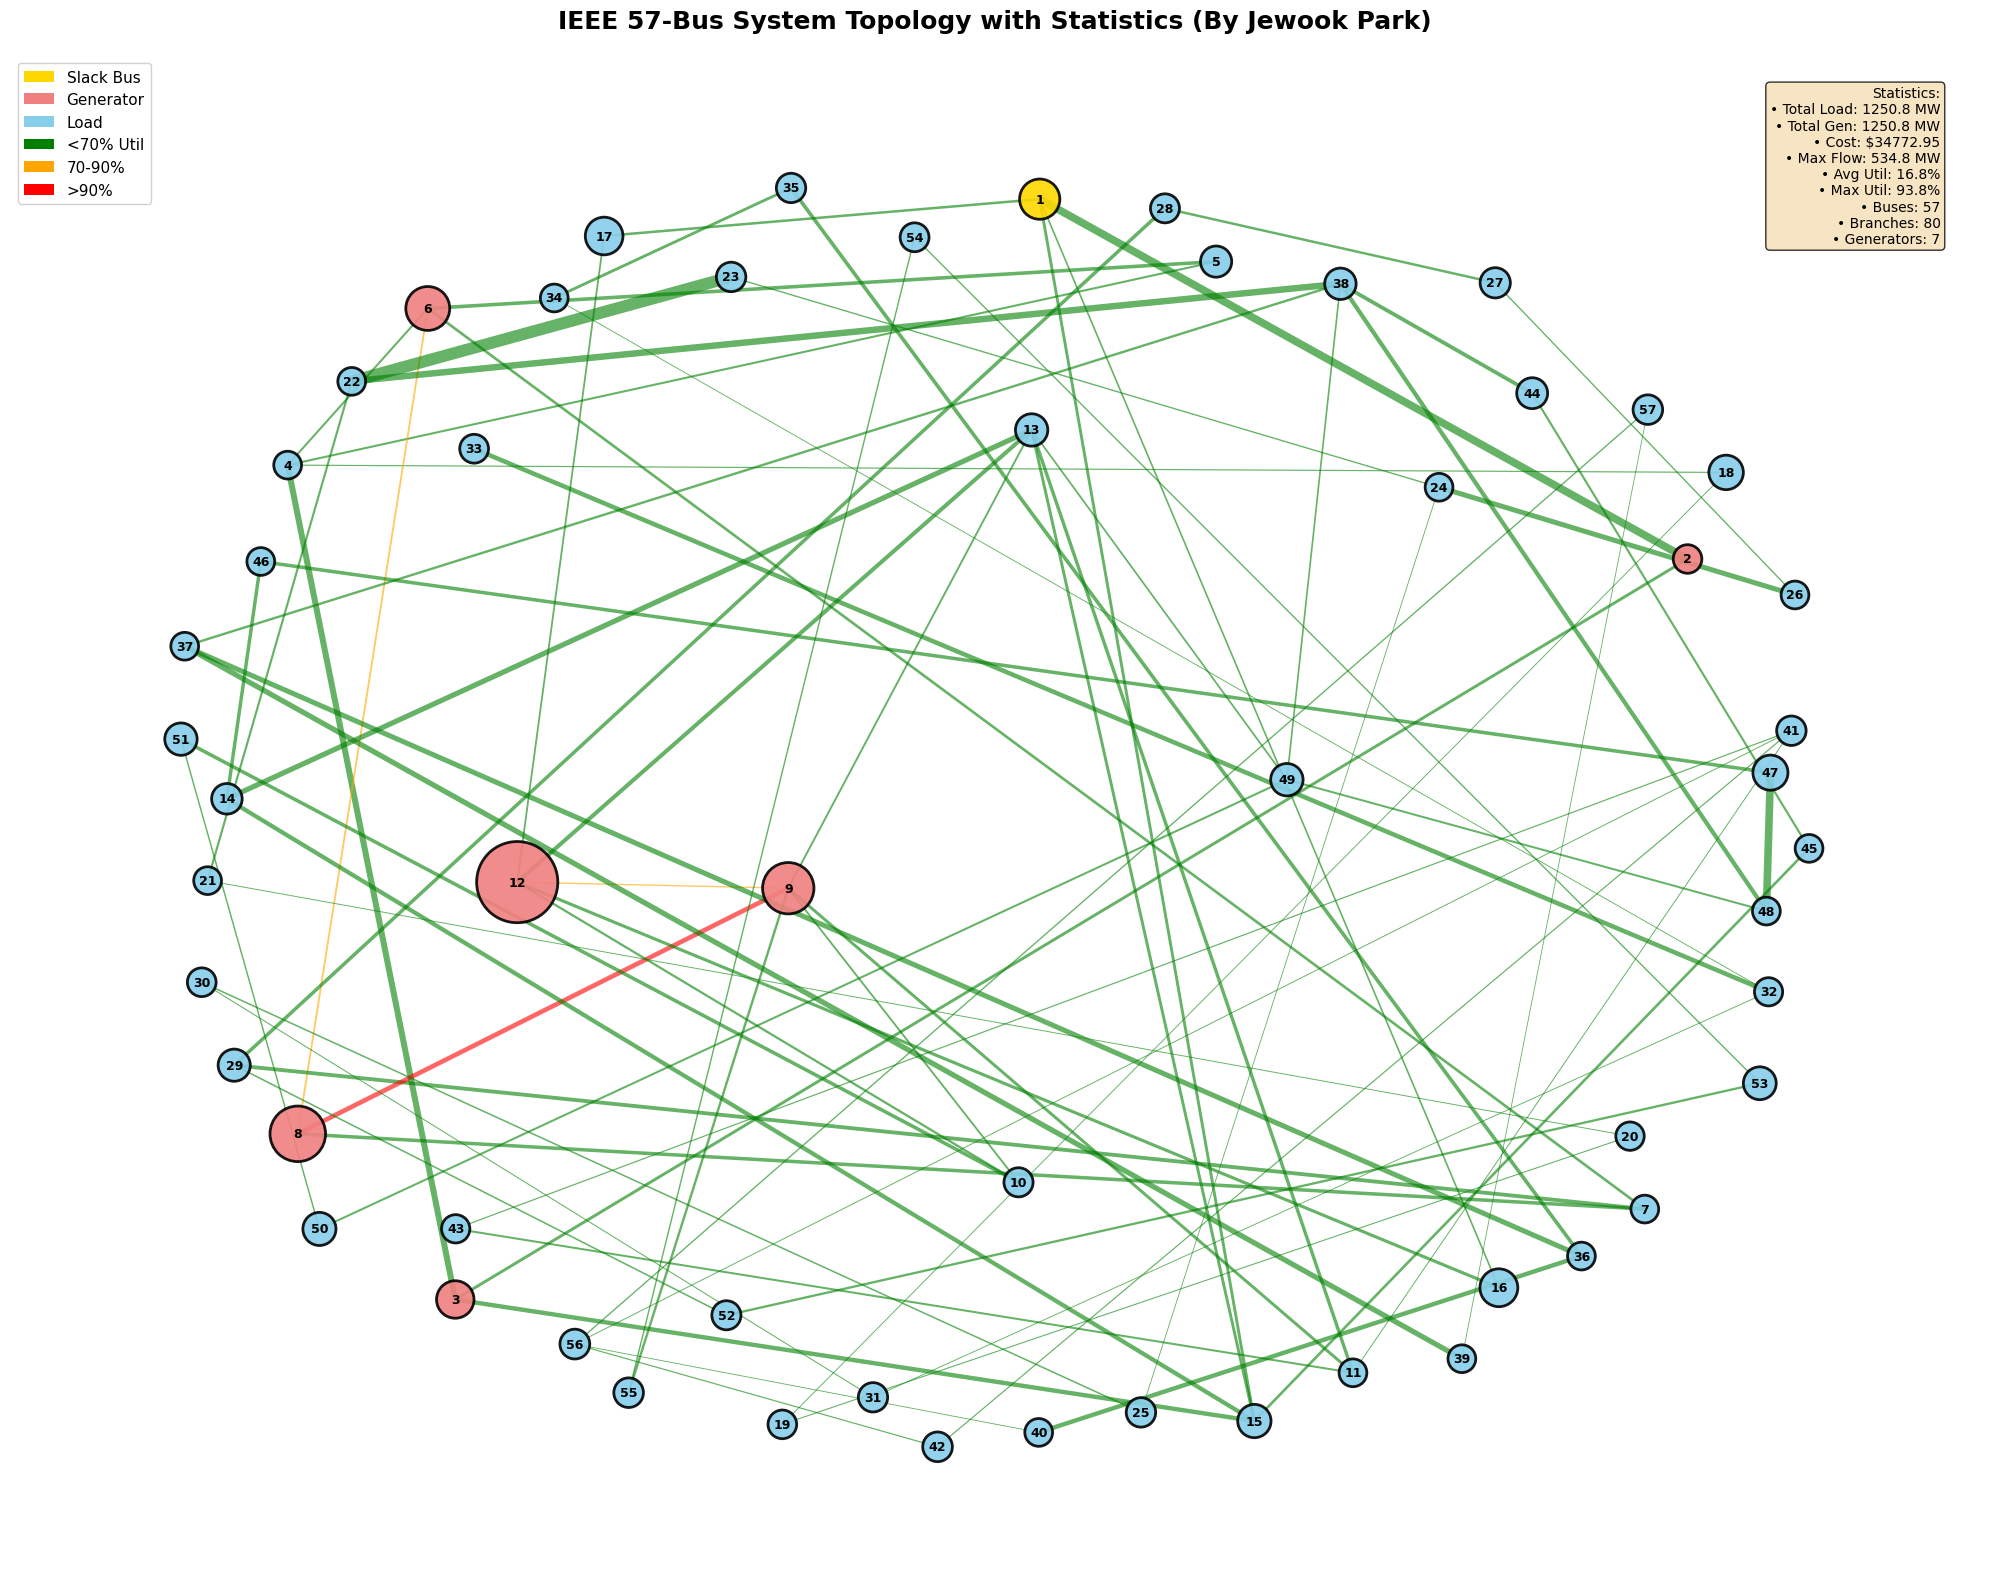

In [10]:
if model.status == GRB.OPTIMAL:
    G = nx.Graph()
    for _, row in bus_df.iterrows():
        G.add_node(int(row['bus_i']), load=row['Pd'], bus_type=row['type'], theta=theta[row['bus_i']].X)
    for idx, row in branch_df.iterrows():
        fb, tb = int(row['fbus']), int(row['tbus'])
        flow, cap = abs(P_line[idx].X), row['rateA']
        util = (flow/cap*100) if cap > 0 else 0
        G.add_edge(fb, tb, flow=flow, cap=cap, util=util, x=row['x'])
    
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    gen_buses = set(gen_df['bus'].astype(int))
    slack = int(bus_df[bus_df['type'] == 3]['bus_i'].values[0])
    node_colors = ['gold' if n==slack else 'lightcoral' if n in gen_buses else 'skyblue' for n in G.nodes]
    node_sizes = [400 + G.nodes[n]['load']*8 for n in G.nodes]
    edge_colors = ['red' if G[u][v]['util']>90 else 'orange' if G[u][v]['util']>70 else 'green' for u,v in G.edges]
    edge_widths = [0.5 + G[u][v]['cap']/200 for u,v in G.edges]
    
    fig, ax = plt.subplots(figsize=(20,16))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=2, edgecolors='black', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6, ax=ax)
    
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='gold', label='Slack Bus'), Patch(facecolor='lightcoral', label='Generator'),
                       Patch(facecolor='skyblue', label='Load'), Patch(facecolor='green', label='<70% Util'),
                       Patch(facecolor='orange', label='70-90%'), Patch(facecolor='red', label='>90%')], 
              loc='upper left', fontsize=11, framealpha=0.9)
    
    total_load, total_gen = bus_df['Pd'].sum(), sum(Pg[g].X for g in Pg)
    max_flow = max(abs(P_line[l].X) for l in P_line)
    avg_util = np.mean([G[u][v]['util'] for u,v in G.edges])
    max_util = max([G[u][v]['util'] for u,v in G.edges])
    
    stats = f"""Statistics:
• Total Load: {total_load:.1f} MW
• Total Gen: {total_gen:.1f} MW
• Cost: ${model.ObjVal:.2f}
• Max Flow: {max_flow:.1f} MW
• Avg Util: {avg_util:.1f}%
• Max Util: {max_util:.1f}%
• Buses: {len(bus_df)}
• Branches: {len(branch_df)}
• Generators: {len(gen_df)}"""
    
    ax.text(0.98, 0.98, stats, transform=ax.transAxes, fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.title('IEEE 57-Bus System Topology with Statistics (By Jewook Park)', fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [13]:
# Visualize the 57-bus system with different configurations

def visualize_multiple_configs(model, bus_df, gen_df, branch_df, Pg, P_line, z=None):
    configs = [
        {'title': 'DC-OPF (No Switching - Baseline)', 'switching': False},
        {'title': 'DC-OPF (With Switching)', 'switching': True},
        {'title': 'DC-OPF at 1.05x Load (No Switching)', 'factor': 1.05, 'switching': False},
        {'title': 'DC-OPF at 1.05x Load (With Switching)', 'factor': 1.05, 'switching': True}
    ]

    fig, axs = plt.subplots(2, 2, figsize=(20, 16))
    axs = axs.flatten()

    for ax, config in zip(axs, configs):
        factor = config.get('factor', 1)
        switching = config['switching']

        G = nx.Graph()
        for _, row in bus_df.iterrows():
            G.add_node(int(row['bus_i']), load=row['Pd'], bus_type=row['type'])
        edges_on, edges_off = [], []
        for idx, row in branch_df.iterrows():
            fbus, tbus = int(row['fbus']), int(row['tbus'])
            if switching and z is not None and z[idx].X < 0.5:
                edges_off.append((fbus, tbus))
            else:
                edges_on.append((fbus, tbus))
            G.add_edge(fbus, tbus)

        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        node_colors = ['gold' if int(bus_df['bus_i'][i]) == 1 else 'lightblue' for i in range(len(bus_df))]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, alpha=0.9, linewidths=2, edgecolors='black', ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
        if edges_on:
            nx.draw_networkx_edges(G, pos, edgelist=edges_on, edge_color='gray', width=2, alpha=0.7, ax=ax)
        if edges_off:
            nx.draw_networkx_edges(G, pos, edgelist=edges_off, edge_color='red', width=2, alpha=0.7, style='dashed', ax=ax)

        cost = model.ObjVal * factor
        ax.set_title(f"{config['title']}\nTotal Cost = ${cost:.2f}", fontsize=14)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Use it: 
# visualize_multiple_configs(model, bus_df, gen_df, branch_df, Pg, P_line, z)
